**Projects**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [2]:
file_path = Path.cwd().parent.parent/"Excel"/"1_Projects.xlsx"
df = pd.read_excel(file_path)
df

,Project_ID,Project_Name,Project_Type,Region,Start_Date,Planned_End_Date,Actual_End_Date,Planned_Budget_Cr,Actual_Cost_Cr,Planned_Progress_Pct,Actual_Progress_Pct,Contractor_ID,Status
0,P1001,Water Supply Project 1,Water Supply,Central,2025-12-13,2026-10-20,2026-10-30,140.97,146.36,100,100,C104,Completed
1,P1002,Tunnel Project 2,Tunnel,Northeast,2022-11-30,2024-08-10,NaN,128.71,128.97,55,59,C106,Ongoing
2,P1003,Metro Project 3,Metro,West,2023-07-07,2025-12-18,2026-02-27,152.97,154.98,100,75,C107,Delayed
3,P1004,Airport Project 4,Airport,North,2025-03-07,2026-09-20,2026-12-19,76.05,78.31,100,100,C104,Completed
4,P1005,Airport Project 5,Airport,Northeast,2024-05-27,2026-09-11,NaN,179.54,197.38,49,53,C110,Ongoing
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,P1248,Highway Project 248,Highway,South,2024-04-25,2026-01-06,NaN,107.89,120.16,43,35,C109,Ongoing
248,P1249,Power Project 249,Power,Northeast,2023-04-30,2024-10-19,2024-11-23,167.28,161.79,100,100,C103,Completed
249,P1250,Railway Project 250,Railway,North,2022-10-06,2025-01-21,2025-01-21,36.27,45.77,100,100,C104,Completed
250,P1251,Bridge Project 99,Bridge,Central,2023-03-12,2024-04-13,2024-06-24,68.22,67.32,100,61,C109,Delayed


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Project_ID            252 non-null    object 
 1   Project_Name          249 non-null    object 
 2   Project_Type          250 non-null    object 
 3   Region                249 non-null    object 
 4   Start_Date            249 non-null    object 
 5   Planned_End_Date      249 non-null    object 
 6   Actual_End_Date       142 non-null    object 
 7   Planned_Budget_Cr     252 non-null    float64
 8   Actual_Cost_Cr        251 non-null    float64
 9   Planned_Progress_Pct  252 non-null    int64  
 10  Actual_Progress_Pct   252 non-null    int64  
 11  Contractor_ID         249 non-null    object 
 12  Status                249 non-null    object 
dtypes: float64(2), int64(2), object(9)
memory usage: 25.7+ KB


In [4]:
df["Project_ID"].duplicated().sum()
df.drop_duplicates(subset=["Project_ID"], inplace=True)

In [5]:
df["Project_Type"] = df["Project_Type"].replace(["Null", "None", ""], np.nan)
df["Project_Type"] = df["Project_Type"].fillna(df["Project_Name"].str.split("Project").str[0])
df["Project_Type"] = df["Project_Type"].str.strip()
df["Project_Type"].unique()

array(['Water Supply', 'Tunnel', 'Metro', 'Airport', 'Bridge', 'Railway',
       'Power', 'Highway'], dtype=object)

In [6]:
df["Region"].unique()
mapping = (
    df.dropna(subset=["Region"])
      .drop_duplicates(subset=["Contractor_ID"])
      .set_index("Contractor_ID")["Region"]
      .to_dict()
)
df["Region"] = df["Region"].fillna(df["Contractor_ID"].map(mapping))
df["Region"].unique()

array(['Central', 'Northeast', 'West', 'North', 'South', 'East'],
      dtype=object)

In [7]:
df[df["Start_Date"].isna()]
file_path2 = Path.cwd().parent.parent/"Excel"/"3_ProjectMilestones.xlsx"
project_milestones = pd.read_excel(file_path2)
project_milestones.drop_duplicates(subset="Project_ID", keep="first", inplace=True)
merge = df.merge( project_milestones, 
                 left_on="Project_ID", 
                 right_on="Project_ID", 
                 how="left"
                )
mapping = (project_milestones.set_index("Project_ID")["Planned_Date"])
df["Start_Date"] = df["Start_Date"].fillna(df["Project_ID"].map(mapping))
df["Start_Date"] = pd.to_datetime(df["Start_Date"], errors="coerce")
df["Start_Date"].isna().sum()

np.int64(6)

In [8]:
df[df["Actual_Cost_Cr"].isna()]
df["Actual_Cost_Cr"] = df["Actual_Cost_Cr"].fillna(df["Actual_Cost_Cr"].median())

In [9]:
df["Planned_End_Date"] = pd.to_datetime(df["Planned_End_Date"], errors="coerce")
def avg_duration():
    return abs((df["Planned_End_Date"] - df["Start_Date"]).dt.days).mean().round(0)
avg_days = avg_duration()
df["Planned_End_Date"] = df["Planned_End_Date"].fillna(df["Start_Date"]+pd.to_timedelta(avg_days, unit="D"))
df["Planned_End_Date"].isna().sum()

np.int64(0)

In [10]:
df["Actual_End_Date"] = pd.to_datetime(df["Actual_End_Date"], errors="coerce")
df[df["Actual_End_Date"].isna()]

,Project_ID,Project_Name,Project_Type,Region,Start_Date,Planned_End_Date,Actual_End_Date,Planned_Budget_Cr,Actual_Cost_Cr,Planned_Progress_Pct,Actual_Progress_Pct,Contractor_ID,Status
1,P1002,Tunnel Project 2,Tunnel,Northeast,2022-11-30,2024-08-10,NaT,128.71,128.97,55,59,C106,Ongoing
4,P1005,Airport Project 5,Airport,Northeast,2024-05-27,2026-09-11,NaT,179.54,197.38,49,53,C110,Ongoing
5,P1006,Metro Project 6,Metro,Northeast,2025-05-06,2026-03-07,NaT,99.01,112.48,83,84,C107,Ongoing
6,P1007,Airport Project 7,Airport,Northeast,2022-08-17,2024-02-08,NaT,8.56,9.60,72,83,C106,Ongoing
7,P1008,Bridge Project 8,Bridge,Northeast,2025-08-01,2027-08-30,NaT,72.31,91.75,78,44,C105,Ongoing
...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,P1235,Power Project 235,Power,North,2024-10-20,2027-04-01,NaT,177.74,188.97,63,26,C104,Ongoing
236,P1237,Power Project 237,Power,West,2024-04-03,2025-02-21,NaT,55.72,61.35,74,44,C112,Ongoing
241,P1242,Railway Project 242,Railway,Northeast,2022-01-06,2022-10-18,NaT,50.06,59.50,94,15,C109,On Hold
243,P1244,Highway Project 244,Highway,South,2024-11-22,2025-09-05,NaT,158.84,162.64,69,28,C104,At Risk


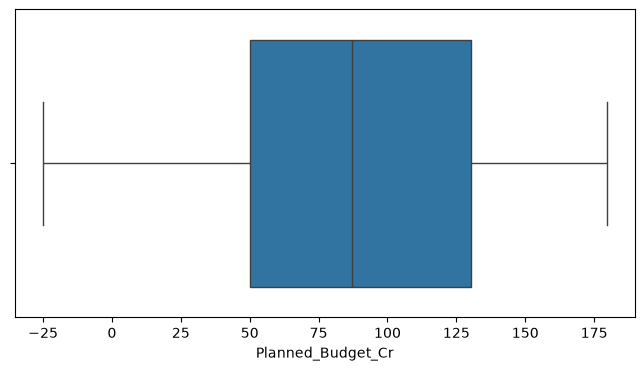

In [11]:
plt.figure(figsize=(8,4))
sb.boxplot(x=df["Planned_Budget_Cr"])
plt.show()

In [12]:
def avg_budget():
    return abs(df["Planned_Budget_Cr"]-df["Actual_Cost_Cr"]).mean()
avg_budget_diff = avg_budget()
df.loc[df["Planned_Budget_Cr"] < 0, "Planned_Budget_Cr"] = df["Actual_Cost_Cr"]-avg_budget_diff
df["Planned_Budget_Cr"]

0      140.97
1      128.71
2      152.97
3       76.05
4      179.54
        ...  
247    107.89
248    167.28
249     36.27
250     68.22
251     54.92
Name: Planned_Budget_Cr, Length: 252, dtype: float64

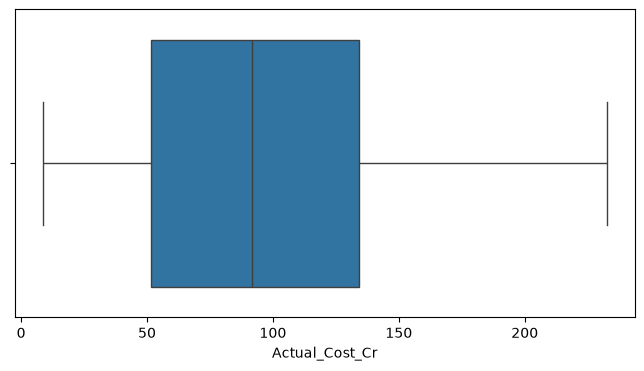

In [13]:
plt.figure(figsize=(8,4))
sb.boxplot(x=df["Actual_Cost_Cr"])
plt.show()

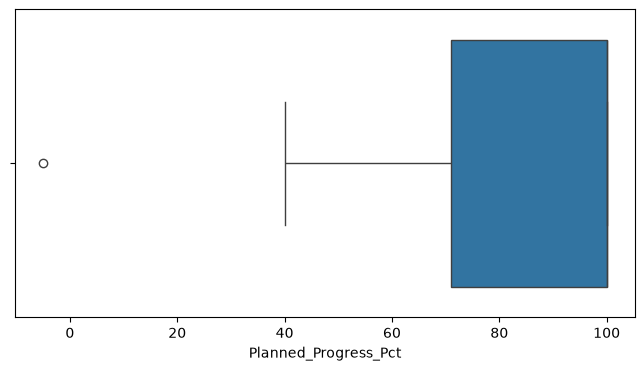

In [14]:
plt.figure(figsize=(8,4))
sb.boxplot(x=df["Planned_Progress_Pct"])
plt.show()

In [15]:
def avg_pct():
    return abs(df["Planned_Progress_Pct"]-df["Actual_Progress_Pct"]).mean().round(0)
avg_progress_diff = avg_pct().round(0)
df.loc[df["Planned_Progress_Pct"] < 0, "Planned_Progress_Pct"] = df["Actual_Progress_Pct"]+avg_progress_diff

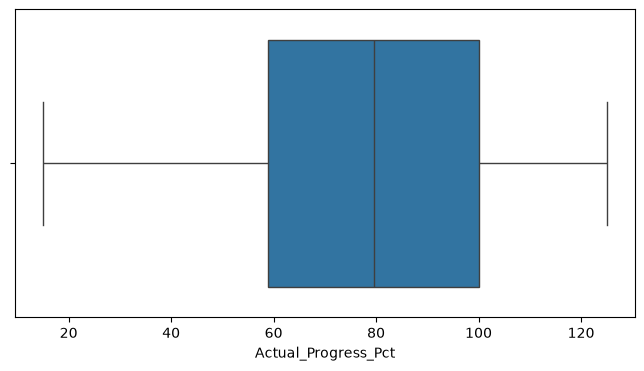

In [16]:
plt.figure(figsize=(8,4))
sb.boxplot(x=df["Actual_Progress_Pct"])
plt.show()

In [17]:
df.loc[df["Actual_Progress_Pct"] > 100, "Actual_Progress_Pct"] = df["Planned_Progress_Pct"]-avg_progress_diff

In [18]:
df["Status"].unique()
df[df["Status"].isna()]
df["Status"] = df["Status"].fillna("Ongoing")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Project_ID            252 non-null    object        
 1   Project_Name          249 non-null    object        
 2   Project_Type          252 non-null    object        
 3   Region                252 non-null    object        
 4   Start_Date            246 non-null    datetime64[ns]
 5   Planned_End_Date      252 non-null    datetime64[ns]
 6   Actual_End_Date       140 non-null    datetime64[ns]
 7   Planned_Budget_Cr     252 non-null    float64       
 8   Actual_Cost_Cr        252 non-null    float64       
 9   Planned_Progress_Pct  252 non-null    int64         
 10  Actual_Progress_Pct   252 non-null    int64         
 11  Contractor_ID         249 non-null    object        
 12  Status                252 non-null    object        
dtypes: datetime64[ns](3)

In [20]:
df.to_csv("../../Data/Cleaned/Projects.csv", index=False) 